In [ ]:
import os
import kagglehub

print("1. Garantindo acesso ao dataset no disco virtual...")
# Baixa ou localiza o dataset direto na estrutura do Google/Kaggle
caminho_virtual = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")
print(f"   [OK] Localizado em: {caminho_virtual}")

print("\n2. Criando pastas de resultados...")
os.makedirs("resultados/figuras", exist_ok=True)
print("   [OK] Pastas 'resultados/figuras' prontas.")

1. Garantindo acesso ao dataset no disco virtual...
Using Colab cache for faster access to the 'ecommerce-events-history-in-cosmetics-shop' dataset.
   [OK] Localizado em: /kaggle/input/ecommerce-events-history-in-cosmetics-shop

2. Criando pastas de resultados...
   [OK] Pastas 'resultados/figuras' prontas.


In [ ]:
import os
import kagglehub

caminho_virtual = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")

# Escreve o arquivo config.py apontando direto para a origem virtual
with open("config.py", "w", encoding="utf-8") as f:
    f.write(f"""import os

# Caminhos apontando para a pasta virtual do Kaggle
PASTA_DADOS = "{caminho_virtual}"
CAMINHO_CSV = os.path.join(PASTA_DADOS, "2019-Oct.csv")
PASTA_RESUTADOS = "resultados"
PASTA_FIGURAS = os.path.join(PASTA_RESUTADOS, "figuras")
ARQUIVO_PARAMETROS = os.path.join(PASTA_RESUTADOS, "parametros.json")
ARQUIVO_MES = "2019-Oct.csv"

# Configurações do algoritmo para não estourar a RAM do Colab
CHUNKSIZE = 250000        # Processa em blocos de 250k linhas
SAMPLE_DIVISOR = 20       # Filtra deterministicamente ~5% das sessoes para estudo
SEED = 42

K_MIN = 2
K_MAX = 5
""")

print("Arquivo 'config.py' criado e configurado com sucesso!")

Using Colab cache for faster access to the 'ecommerce-events-history-in-cosmetics-shop' dataset.
Arquivo 'config.py' criado e configurado com sucesso!


In [ ]:
%%writefile etapa2_caracterizacao.py
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # roda em background sem travar o servidor
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import config

def preparar_pastas():
    os.makedirs(config.PASTA_FIGURAS, exist_ok=True)

def salvar_figura(nome):
    caminho = os.path.join(config.PASTA_FIGURAS, nome)
    plt.tight_layout()
    plt.savefig(caminho, dpi=120)
    plt.close()
    print(f"   [figura salva] {caminho}")

def titulo(texto):
    print("\n" + "=" * 70)
    print(texto)
    print("=" * 70)

def carregar_amostra_e_lambda():
    titulo("PASSO 1 - Leitura amostrada do dataset e taxa de chegada (lambda)")
    if not os.path.exists(config.CAMINHO_CSV):
        raise SystemExit(f"ERRO: arquivo nao encontrado: {config.CAMINHO_CSV}")

    print(f"Lendo direto de: {config.CAMINHO_CSV}")
    print(f"Amostragem: Mantendo sessoes completas na proporcao 1/{config.SAMPLE_DIVISOR}")

    colunas = ["event_time", "event_type", "product_id", "brand", "price", "user_id", "user_session"]
    pedacos_amostra = []
    contagem_por_segundo = {}
    total_eventos = 0

    leitor = pd.read_csv(config.CAMINHO_CSV, usecols=colunas, chunksize=config.CHUNKSIZE)

    for i, chunk in enumerate(leitor):
        total_eventos += len(chunk)

        # Lambda por segundo
        segs = chunk["event_time"].str.slice(0, 19)
        vc = segs.value_counts()
        for ts, n in vc.items():
            contagem_por_segundo[ts] = contagem_por_segundo.get(ts, 0) + int(n)

        # Amostragem hash estável
        s = chunk["user_session"].astype("string").fillna("")
        mascara = (pd.util.hash_pandas_object(s, index=False) % config.SAMPLE_DIVISOR == 0)
        pedacos_amostra.append(chunk[mascara])

        if (i+1) % 4 == 0 or i == 0:
            print(f"   Progresso: {total_eventos:,} linhas processadas...")

    df = pd.concat(pedacos_amostra, ignore_index=True)
    print(f"\nTotal de eventos processados no mes: {total_eventos:,}")
    print(f"Eventos retidos na amostra para analise: {len(df):,}")

    contagens = np.array(list(contagem_por_segundo.values()), dtype=float)
    lambda_medio = float(contagens.mean())
    lambda_pico = float(np.percentile(contagens, 99))
    print(f"--> Lambda Medio: {lambda_medio:.2f} req/s | Lambda Pico (P99): {lambda_pico:.2f} req/s")

    return df, lambda_medio, lambda_pico

def sumarizacao_estatistica(df):
    titulo("PASSO 2 - Sumarizacao estatistica e Graficos")
    cont_eventos = df["event_type"].value_counts()

    plt.figure(figsize=(7, 4))
    cont_eventos.plot(kind="bar", color="#4C72B0")
    plt.title("Distribuicao de eventos por tipo")
    plt.xticks(rotation=20)
    salvar_figura("01_eventos_por_tipo.png")

    preco = df["price"].dropna()
    preco = preco[preco > 0]
    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(preco), bins=50, color="#55A868")
    plt.title("Histograma de preco (escala log1p)")
    salvar_figura("02_histograma_preco.png")

    eventos_por_sessao = df.groupby("user_session").size()
    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(eventos_por_sessao), bins=40, color="#C44E52")
    plt.title("Histograma de eventos por sessao (escala log1p)")
    salvar_figura("03_eventos_por_sessao.png")

    top_marcas = df["brand"].value_counts().head(10)
    plt.figure(figsize=(7, 4))
    top_marcas.iloc[::-1].plot(kind="barh", color="#8172B3")
    plt.title("Top 10 marcas")
    salvar_figura("04_top_marcas.png")

def construir_features_sessao(df):
    titulo("PASSO 3 - Engenharia de Features por Sessao")
    df["event_time"] = pd.to_datetime(df["event_time"], format="mixed", utc=True, errors="coerce")
    df["is_view"] = (df["event_type"] == "view").astype(int)
    df["is_cart"] = (df["event_type"] == "cart").astype(int)
    df["is_remove"] = (df["event_type"] == "remove_from_cart").astype(int)
    df["is_purchase"] = (df["event_type"] == "purchase").astype(int)
    df["valor_purchase"] = df["price"].where(df["is_purchase"] == 1, 0.0)

    g = df.groupby("user_session")
    feats = pd.DataFrame({
        "n_view": g["is_view"].sum(),
        "n_cart": g["is_cart"].sum(),
        "n_remove": g["is_remove"].sum(),
        "n_purchase": g["is_purchase"].sum(),
        "n_eventos": g.size(),
        "n_produtos": g["product_id"].nunique(),
        "duracao_seg": (g["event_time"].max() - g["event_time"].min()).dt.total_seconds(),
        "valor_compras": g["valor_purchase"].sum(),
        "preco_medio": g["price"].mean(),
    }).fillna(0.0)
    print(f"Matriz de features estruturada: {len(feats):,} sessoes exclusivas.")
    return feats

def preparar_para_pca(feats):
    titulo("PASSO 4 - Transformacao Log, Outliers e Padronizacao")
    X = feats.copy()
    for col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

    limite = X["n_eventos"].quantile(0.99)
    mascara = X["n_eventos"] <= limite
    X = X[mascara]
    feats_filtrado = feats[mascara]

    scaler = StandardScaler()
    X_pad = scaler.fit_transform(X.values)
    return X_pad, feats_filtrado

def aplicar_pca(X_pad, nomes_features):
    titulo("PASSO 5 - PCA (Analise de Componentes Principais)")
    pca = PCA()
    componentes = pca.fit_transform(X_pad)
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    n80 = int(np.searchsorted(var_acum, 0.80) + 1)

    print("\nVariancia acumulada por componente:")
    for idx, va in enumerate(var_acum[:4]):
        print(f"   PC{idx+1}: {va*100:.2f}% acumulado")

    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(var_acum) + 1), var_acum * 100, "o-", color="#C44E52")
    plt.axhline(80, ls="--", color="gray")
    plt.title("Scree plot - Variancia Explicada Acumulada")
    salvar_figura("05_pca_scree.png")
    return componentes, n80

def clusterizar(componentes, n_componentes, feats_filtrado):
    titulo("PASSO 6 - Clusterizacao K-Means (Descobrindo Perfis)")
    X = componentes[:, :max(n_componentes, 2)]
    ks = list(range(config.K_MIN, config.K_MAX + 1))
    inercias, silhuetas = [], []

    idx_sil = np.random.default_rng(config.SEED).choice(len(X), min(len(X), 15000), replace=False)

    for k in ks:
        km = KMeans(n_clusters=k, random_state=config.SEED, n_init=10)
        rotulos = km.fit_predict(X)
        inercias.append(km.inertia_)
        silhuetas.append(silhouette_score(X[idx_sil], rotulos[idx_sil]))

    k_otimo = ks[int(np.argmax(silhuetas))]
    print(f"Melhor numero de clusters detectado (Silhueta): k={k_otimo}")

    km = KMeans(n_clusters=k_otimo, random_state=config.SEED, n_init=10)
    rotulos = km.fit_predict(X)

    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=rotulos, cmap="tab10", s=6, alpha=0.4)
    plt.title(f"Clusters no Espaco PCA (k={k_otimo})")
    salvar_figura("07_clusters_pca.png")

    resumo = feats_filtrado.copy()
    resumo["cluster"] = rotulos
    perfil = resumo.groupby("cluster").mean().round(2)

    print("\n--- Metricas Medias Reais por Grupo Encontrado ---")
    print(perfil.to_string())
    return perfil

def salvar_parametros(lambda_medio, lambda_pico):
    params = {
        "lambda_medio_reqs": round(lambda_medio, 4),
        "lambda_pico_reqs": round(lambda_pico, 4),
        "obs": "Dados extraidos sem duplicar arquivos fisicos no Colab."
    }
    with open(config.ARQUIVO_PARAMETROS, "w", encoding="utf-8") as f:
        json.dump(params, f, indent=2, ensure_ascii=False)
    print(f"\n[Salvo] Parametros para Engenharia de Filas em: {config.ARQUIVO_PARAMETROS}")

def main():
    preparar_pastas()
    df, lambda_medio, lambda_pico = carregar_amostra_e_lambda()
    sumarizacao_estatistica(df)
    feats = construir_features_sessao(df)
    X_pad, feats_filtrado = preparar_para_pca(feats)
    componentes, n80 = aplicar_pca(X_pad, list(feats.columns))
    clusterizar(componentes, n80, feats_filtrado)
    salvar_parametros(lambda_medio, lambda_pico)
    titulo("ETAPA 2 FINALIZADA COM SUCESSO!")

if __name__ == "__main__":
    main()

Writing etapa2_caracterizacao.py


In [ ]:
%run etapa2_caracterizacao.py


PASSO 1 - Leitura amostrada do dataset e taxa de chegada (lambda)
Lendo direto de: /kaggle/input/ecommerce-events-history-in-cosmetics-shop/2019-Oct.csv
Amostragem: Mantendo sessoes completas na proporcao 1/20
   Progresso: 250,000 linhas processadas...
   Progresso: 1,000,000 linhas processadas...
   Progresso: 2,000,000 linhas processadas...
   Progresso: 3,000,000 linhas processadas...
   Progresso: 4,000,000 linhas processadas...

Total de eventos processados no mes: 4,102,283
Eventos retidos na amostra para analise: 204,183
--> Lambda Medio: 2.30 req/s | Lambda Pico (P99): 8.00 req/s

PASSO 2 - Sumarizacao estatistica e Graficos
   [figura salva] resultados/figuras/01_eventos_por_tipo.png
   [figura salva] resultados/figuras/02_histograma_preco.png
   [figura salva] resultados/figuras/03_eventos_por_sessao.png
   [figura salva] resultados/figuras/04_top_marcas.png

PASSO 3 - Engenharia de Features por Sessao
Matriz de features estruturada: 43,703 sessoes exclusivas.

PASSO 4 - Tr


📈 Arquivo gerado: 01_eventos_por_tipo.png


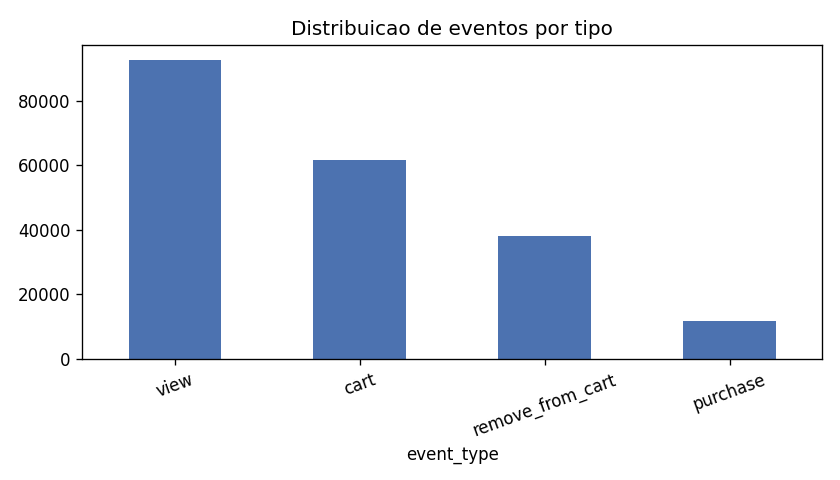


📈 Arquivo gerado: 02_histograma_preco.png


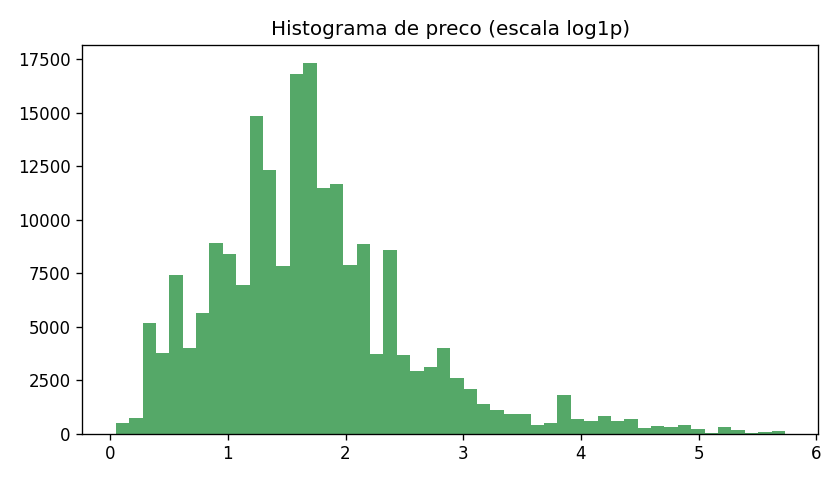


📈 Arquivo gerado: 03_eventos_por_sessao.png


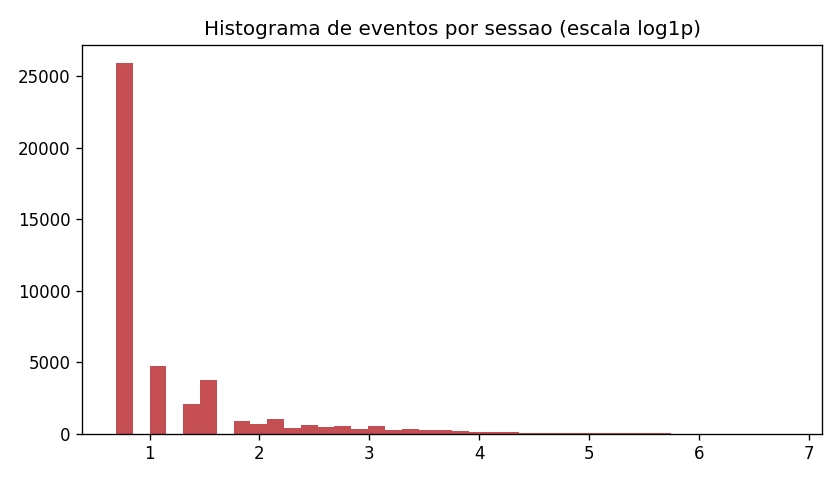


📈 Arquivo gerado: 04_top_marcas.png


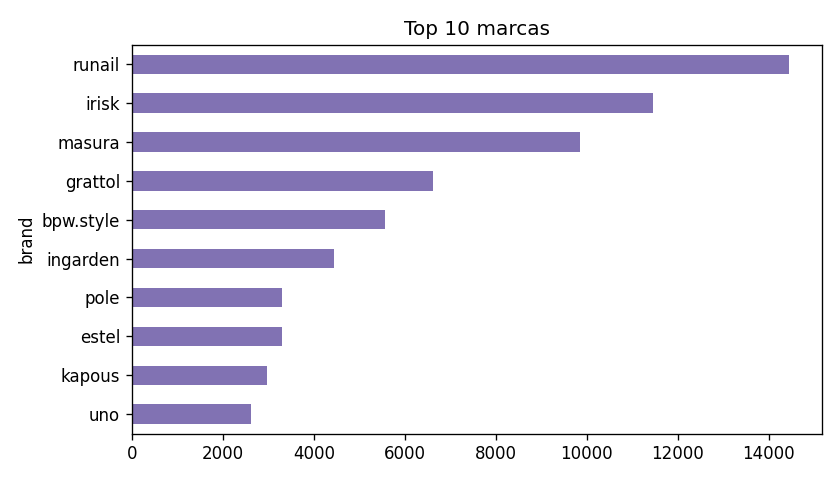


📈 Arquivo gerado: 05_pca_scree.png


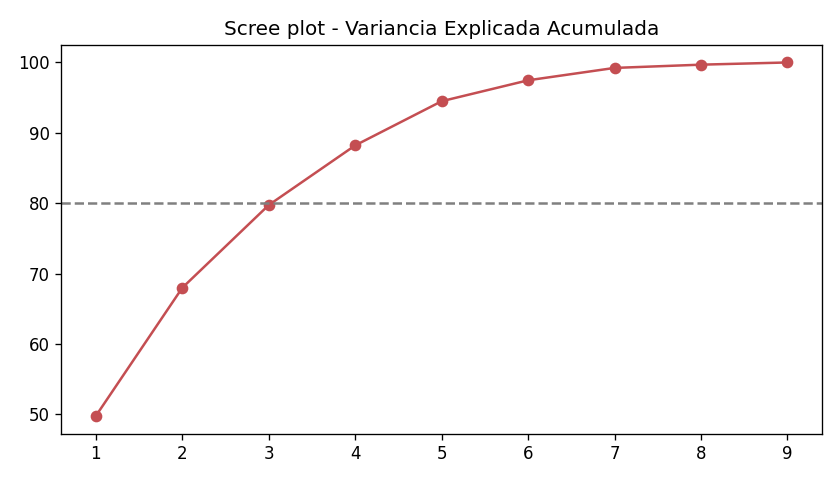


📈 Arquivo gerado: 07_clusters_pca.png


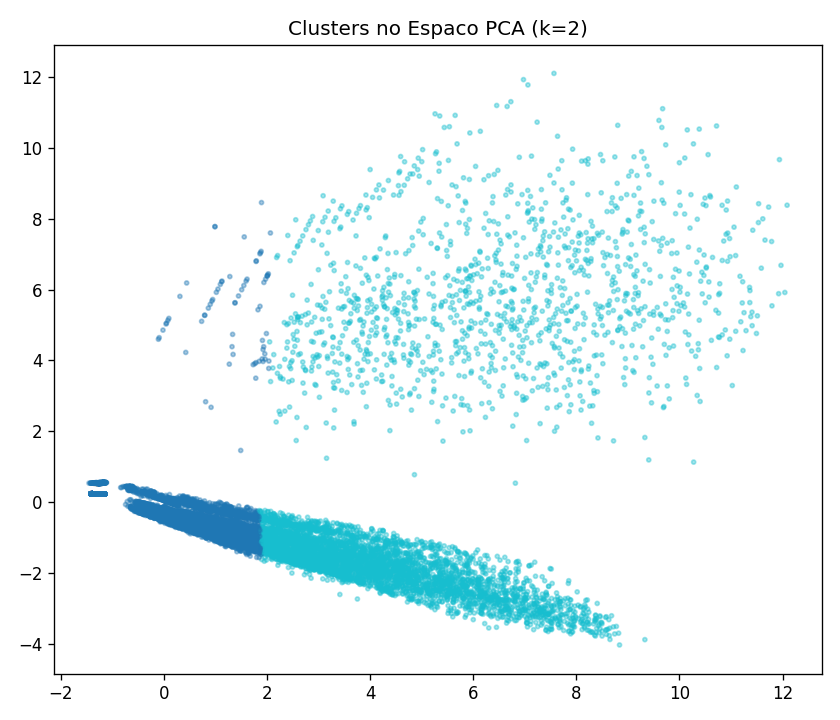

In [ ]:
from IPython.display import Image, display
import os

pasta_figuras = "resultados/figuras"
if os.path.exists(pasta_figuras):
    for imagem in sorted(os.listdir(pasta_figuras)):
        print(f"\n📈 Arquivo gerado: {imagem}")
        display(Image(filename=os.path.join(pasta_figuras, imagem)))
else:
    print("Nenhum gráfico encontrado. Ocorreu algum erro na execução?")